In [ ]:
import json
import os
from openai import OpenAI
from dotenv import load_dotenv
import subprocess
from utils import lined_print, framed_print
import sys

# 加载 .env 文件
load_dotenv(override=True)

client = OpenAI()

In [2]:
TOOLS = [
    {
        "type": "function",
        "function": {
            "name": "execute_python",
            "description": "使用该工具执行Python代码",
            "parameters": {
                "type": "object",
                "properties": {
                    "code": {
                        "type": "string",
                        "description": "Python代码",
                    }
                },
                "required": ["code"]
            },
        }
    },
]

def execute_python(code: str) -> str:
    """执行Python代码并返回结果。"""
    try:
        print("##执行代码:\n", code)
        # 创建本地环境执行代码
        local_vars = {}
        exec(code, {}, local_vars)  # python可以动态执行代码
        result = local_vars.get('result', '执行成功')
        print("##执行结果:\n", result)
        return str(result)
    except Exception as e:
        return f"Error executing code: {str(e)}"

In [3]:
def send_messages(messages):
    response = client.chat.completions.create(
        model="ZhipuAI/GLM-5.2",
        messages=messages,
        tools=TOOLS,
        tool_choice="auto",
        extra_body={"reasoning_split": True},
    )
    return response

def agent_loop(messages):
    max_rounds = 20
    current_round = 0

    while True:
        current_round += 1
        lined_print(f"Calling LLM (round {current_round})")

        if current_round > max_rounds:
            print(f"Maximum rounds {max_rounds} reached, exiting")
            sys.exit(0)

        response = send_messages(messages)
        message = response.choices[0].message

        reasoning_details = getattr(message, "reasoning_details", None) or []
        if reasoning_details and reasoning_details[0].get('text'):
            framed_print(f"Thinking", reasoning_details[0]['text'], "info")

        if message.content:
            framed_print(f"Answer", message.content, "info")

        if message.tool_calls != None:
            messages.append(message)
            
            for tool_call in response.choices[0].message.tool_calls:
                if tool_call.function.name == "execute_python":
                    arguments_dict = json.loads(tool_call.function.arguments)
                    result = execute_python(arguments_dict['code'])
                    
                    messages.append({
                        "role": "tool",
                        "content": result,
                        "tool_call_id": tool_call.id
                    })
        else:
            break




──────────────────────────── Calling LLM (round 1) ─────────────────────────────
┌───── Answer ─────────────────────────────────────────────────────────────────┐
│ 我来帮你完成这个任务。首先，让我读取CSV文件，了解数据结构，然后计算移动平均  │
│ 线并绘图。                                                                   │
└──────────────────────────────────────────────────────────────────────────────┘
##执行代码:
 
import pandas as pd

# 读取CSV文件
df = pd.read_csv('yanjing_beer_daily_k_20250518_20260518.csv')

# 查看数据基本信息
print("数据形状:", df.shape)
print("\n列名:", df.columns.tolist())
print("\n前5行数据:")
print(df.head())
print("\n数据类型:")
print(df.dtypes)

数据形状: (242, 12)

列名: ['日期', '股票代码', '开盘', '收盘', '最高', '最低', '成交量', '成交额', '振幅', '涨跌幅', '涨跌额', '换手率']

前5行数据:
           日期  股票代码     开盘     收盘     最高     最低     成交量           成交额    振幅  \
0  2025-05-19   729  12.66  12.86  12.88  12.62  168758  2.209451e+08  2.04   
1  2025-05-20   729  12.81  13.12  13.21  12.79  244614  3.261136e+08  3.27   
2  2025-05-21   729  13.10  13.12  13.29

<string>:54: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
<string>:54: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
<string>:54: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) DejaVu Sans.
<string>:54: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) DejaVu Sans.
<string>:54: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
<string>:54: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) DejaVu Sans.
<string>:54: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
<string>:54: UserWarning: Glyph 29141 (\N{CJK UNIFIED IDEOGRAPH-71D5}) missing from font(s) DejaVu Sans.
<string>:54: UserWarning: Glyph 20140 (\N{CJK UNIFIED IDEOGRAPH-4EAC}) missing from font(s) DejaVu Sans.
<string>:54: UserWarning: Glyph 21860 (\N{CJK UNIFIED 

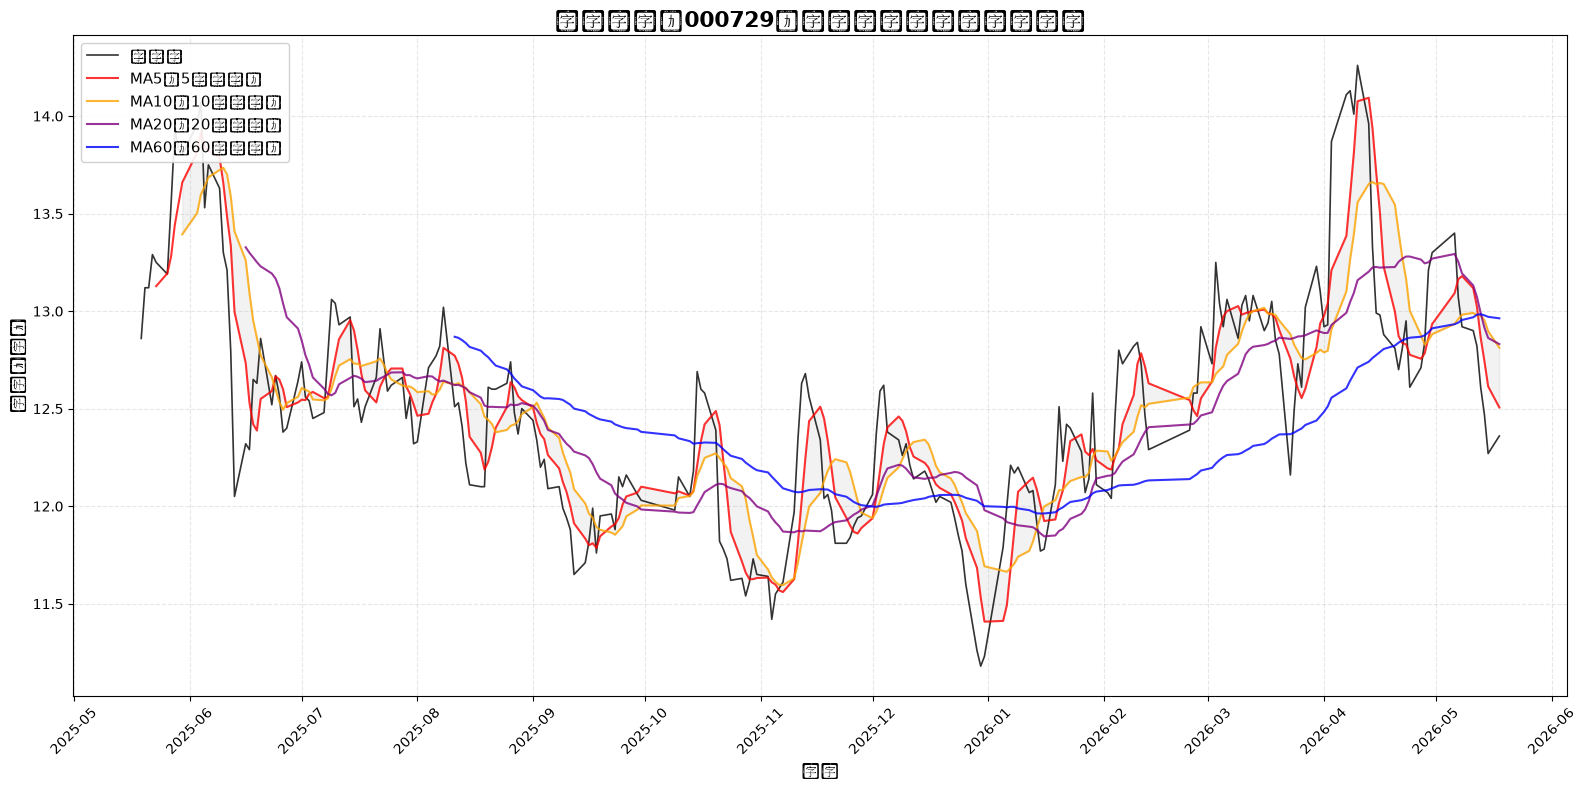

图表已保存为 yanjing_beer_ma_chart.png

最近10天移动平均线数据:
            日期     收盘     MA5    MA10     MA20       MA60
232 2026-04-30  13.30  12.934  12.882  13.2695  12.912000
233 2026-05-06  13.40  13.092  12.934  13.2930  12.933000
234 2026-05-07  13.07  13.164  12.960  13.2530  12.941167
235 2026-05-08  12.92  13.180  12.982  13.1935  12.954667
236 2026-05-11  12.90  13.118  12.991  13.1320  12.968500
237 2026-05-12  12.82  13.022  12.978  13.0725  12.981500
238 2026-05-13  12.61  12.864  12.978  12.9900  12.984000
239 2026-05-14  12.47  12.744  12.954  12.9155  12.978500
240 2026-05-15  12.27  12.614  12.897  12.8625  12.970833
241 2026-05-18  12.36  12.506  12.812  12.8310  12.963167
##执行结果:
             日期     收盘     MA5    MA10     MA20       MA60
232 2026-04-30  13.30  12.934  12.882  13.2695  12.912000
233 2026-05-06  13.40  13.092  12.934  13.2930  12.933000
234 2026-05-07  13.07  13.164  12.960  13.2530  12.941167
235 2026-05-08  12.92  13.180  12.982  13.1935  12.954667
236 2026-05-11 

In [4]:
# 注意这里增加了 f-string 前缀以正确解析 os.getcwd()
SYSTEM_MESSAGE = f"""
你是一个在 {os.getcwd()} 目录下的能够编写和执行代码的智能助手。当用户提出问题时，你需要：
1. 分析问题并确定需要编写什么代码
2. 编写能解决问题的Python代码
3. 使用execute_python工具执行代码
4. 分析执行结果，如果有错误则修改代码再次执行
5. 最终给用户提供答案

请确保你的代码能够正确执行并将最终结果存储在名为'result'的变量中。
本地虚拟环境，使用uv管理, pip包存储位置 .venv
"""

history = [{"role": "system", "content": SYSTEM_MESSAGE}]

while True:
    try:
        query = input("\033[36muser >> \033[0m")
    except (EOFError, KeyboardInterrupt):
        break
        
    if query.strip().lower() in ("q", "exit", ""):
        print("会话已结束。")
        break
        
    history.append({"role": "user", "content": query})
    agent_loop(history)
    response_content = history[-1]["content"]
    print(response_content)
    print()